Here, I will demonstrate how we run simulations with self-gravity.

In [1]:
from galpy.potential import PlummerPotential
from galpy.df import isotropicPlummerdf
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from ezfalcon.tools import mkPlummer_galpy

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

# Add particles

In [2]:
# pot = PlummerPotential(amp=1e10*u.Msun, b=2*u.kpc)
# df = isotropicPlummerdf(pot=pot)
# pos, vel, masses = galpydfsampler(df, n=5000, m_total=1e10)

In [40]:
from ezfalcon.simulation import Sim

def mkSim():
    sim = Sim()

    #Stars
    pos, vel, masses = mkPlummer_galpy(m=1e8, b = 1, n=5000)
    sim.add_particles('stars', pos, vel, mass=masses)

    # DM
    pos, vel, masses = mkPlummer_galpy(m=1e11, b = 2, n=2000)
    sim.add_particles('dm', pos, vel, mass=masses)
    return sim

sim = mkSim()

Text(0.5, 1.0, 'Isotropic Hernquist DF Sampling')

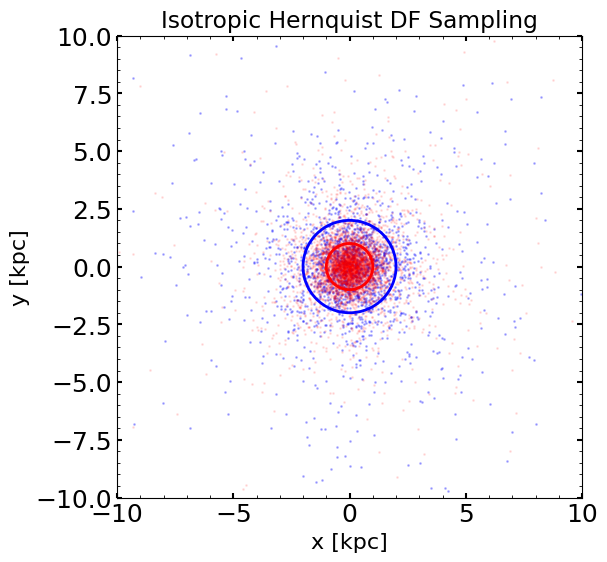

In [44]:
plt.figure(figsize=(6,6))
# plot DM
plt.scatter(sim.dm.x(), sim.dm.y(), s=1, c='b', alpha=0.25)
circle2 = plt.Circle((0, 0), 2, color='b', fill=False, label='Scale Radius', lw=2)


# plot stars
plt.scatter(sim.stars.x(), sim.stars.y(), s=1, c='r', alpha=0.1)
circle = plt.Circle((0, 0), 1, color='r', fill=False, label='Scale Radius', lw=2)

plt.gca().add_artist(circle)
plt.gca().add_artist(circle2)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title('Isotropic Hernquist DF Sampling')

# Running the simulation

In [46]:
# Options for smoothing length:


# 1) Same smoothing length for all particles
sim_const = mkSim()
sim_const.run(t_end=100, dt=1, dt_out=1, eps=0.01, theta=0.5, kernel=1)

# 2) Different smoothing lengths for each components
sim_dif_comps = mkSim()
sim_dif_comps.run(t_end=100, dt=1, dt_out=1, eps={'stars': 0.01, 'dm': 0.005}, theta=0.5, kernel=1)

# 3) Different smoothing lengths for each particle (e.g. based on local density)
sim_dif_particles = mkSim()
stars_eps = np.abs(np.random.normal(scale=0.01, size=len(sim.stars.x(0))))
dm_eps = np.abs(np.random.normal(scale=0.5, size=len(sim.dm.x(0))))
sim_dif_particles.run(t_end=100, dt=1, dt_out=1, eps={'stars': stars_eps, 'dm': dm_eps}, theta=0.5, kernel=1)


# 4) different smoothing lengths for each particle in some components,
# constant for others
sim_some_const_some_dif = mkSim()
stars_eps = np.abs(np.random.normal(scale=0.01, size=len(sim_some_const_some_dif.stars.x(0))))
sim_some_const_some_dif.run(t_end=100, dt=1, dt_out=1, eps={'stars': stars_eps, 'dm': 0.5}, theta=0.5, kernel=1)


100%|██████████| 100/100 [00:02<00:00, 44.71it/s]


# Diagnostics

/geir_data/scr/gabrielspace/ezfalcon/ezfalcon/simulation/simulation.py:1039: UserWarning: Computing external potential on-the-fly for multiple snapshots may be slow.
  warnings.warn("Computing external potential on-the-fly for multiple snapshots may be slow.")



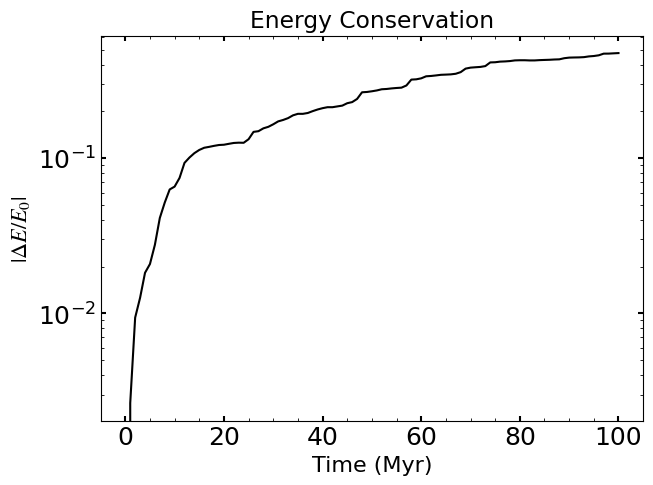

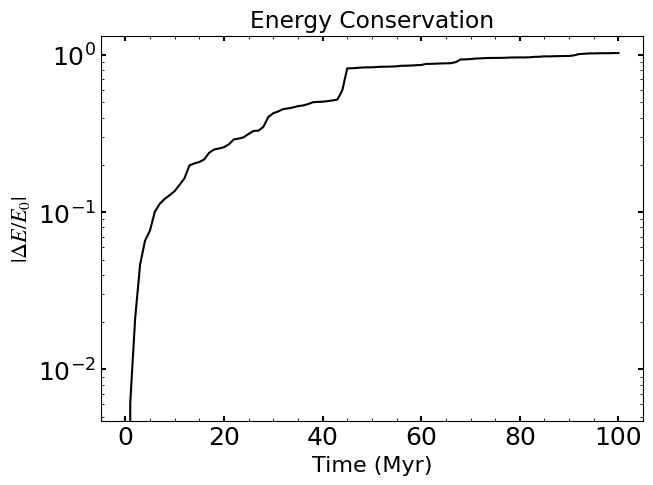

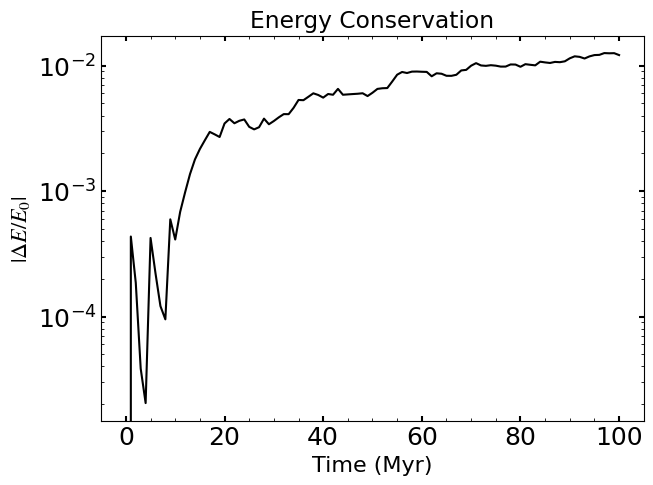

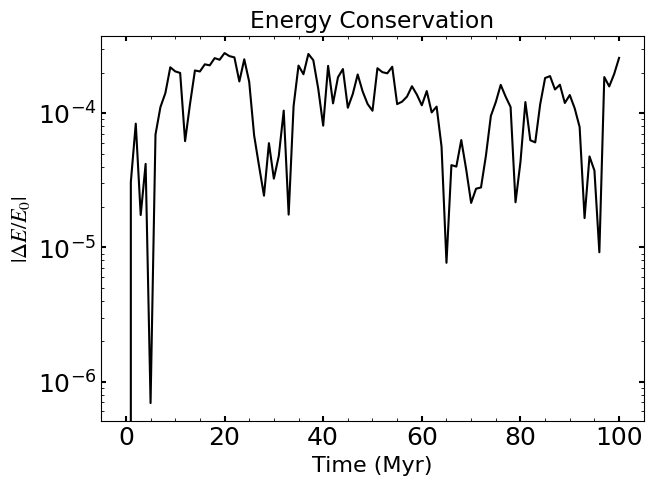

In [47]:
# calculated with same technique as for the integration
# 
sim_const.plot_energy_diagnostic()
sim_dif_comps.plot_energy_diagnostic()
sim_dif_particles.plot_energy_diagnostic()
sim_some_const_some_dif.plot_energy_diagnostic()